<a href="https://colab.research.google.com/github/manavpatel2910/Manav2910/blob/Manav/Python_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/RILO - Copy.csv')
display(df.head())

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
0,RELIANCE,EQ,1-Jan-16,1014.60,1009.80,1018.9,1008.20,1013.6,1015.35,1015.52,1238135,1.257353e+09,30701,529539,42.77
1,RELIANCE,EQ,4-Jan-16,1015.35,1005.00,1013.8,986.70,993.2,995.30,998.91,6896571,6.889070e+09,66235,4974602,72.13
2,RELIANCE,EQ,5-Jan-16,995.30,1000.30,1010.0,997.00,1005.0,1005.15,1003.41,3416459,3.428125e+09,59935,1987804,58.18
3,RELIANCE,EQ,6-Jan-16,1005.15,1007.60,1038.4,1000.40,1029.1,1032.20,1028.15,6116855,6.289073e+09,160947,2912662,47.62
4,RELIANCE,EQ,7-Jan-16,1032.20,1021.05,1028.0,1008.05,1018.9,1013.25,1016.73,4512219,4.587700e+09,105075,2474491,54.84


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Symbol                  1324 non-null   object 
 1   Series                  1324 non-null   object 
 2   Date                    1324 non-null   object 
 3   Prev Close              1324 non-null   float64
 4   Open Price              1324 non-null   float64
 5   High Price              1324 non-null   float64
 6   Low Price               1324 non-null   float64
 7   Last Price              1324 non-null   float64
 8   Close Price             1324 non-null   float64
 9   Average Price           1324 non-null   float64
 10  Total Traded Quantity   1324 non-null   int64  
 11  Turnover                1324 non-null   float64
 12  No. of Trades           1324 non-null   int64  
 13  Deliverable Qty         1324 non-null   int64  
 14  % Dly Qt to Traded Qty  1324 non-null   

In [ ]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

# Extract month and day of week as new categorical features
df['Month'] = df['Date'].dt.month_name()
df['Day_of_Week'] = df['Date'].dt.day_name()

display(df.head())

,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty,Month,Day_of_Week
0,RELIANCE,EQ,2016-01-01,1014.60,1009.80,1018.9,1008.20,1013.6,1015.35,1015.52,1238135,1.257353e+09,30701,529539,42.77,January,Friday
1,RELIANCE,EQ,2016-01-04,1015.35,1005.00,1013.8,986.70,993.2,995.30,998.91,6896571,6.889070e+09,66235,4974602,72.13,January,Monday
2,RELIANCE,EQ,2016-01-05,995.30,1000.30,1010.0,997.00,1005.0,1005.15,1003.41,3416459,3.428125e+09,59935,1987804,58.18,January,Tuesday
3,RELIANCE,EQ,2016-01-06,1005.15,1007.60,1038.4,1000.40,1029.1,1032.20,1028.15,6116855,6.289073e+09,160947,2912662,47.62,January,Wednesday
4,RELIANCE,EQ,2016-01-07,1032.20,1021.05,1028.0,1008.05,1018.9,1013.25,1016.73,4512219,4.587700e+09,105075,2474491,54.84,January,Thursday


Now that we have 'Month' and 'Day of Week' as categorical variables, let's compare the average 'Close Price' for each month using a bar chart.

We can also compare the average 'Close Price' by 'Day of Week'.

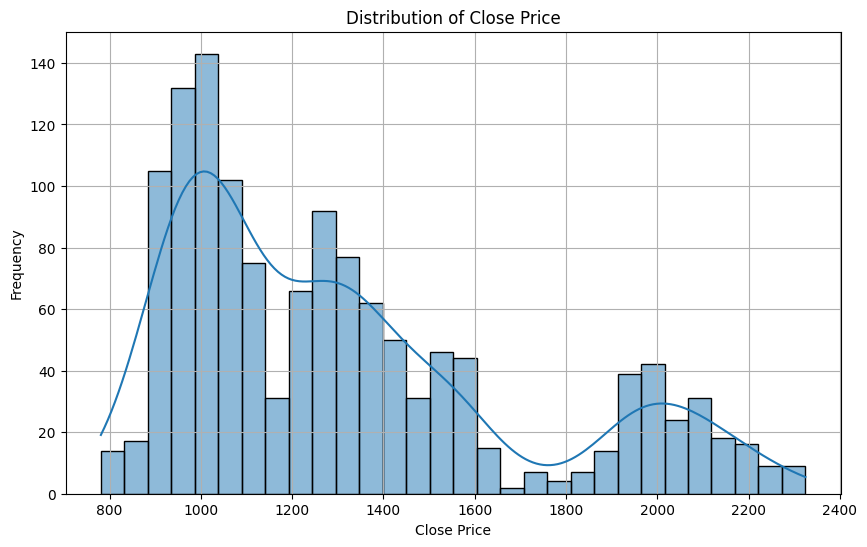

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Close Price'], kde=True, bins=30)
plt.title('Distribution of Close Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**Insight:** The 'Close Price' distribution appears somewhat skewed, suggesting periods of both higher and lower price points, with a central tendency around a specific value.

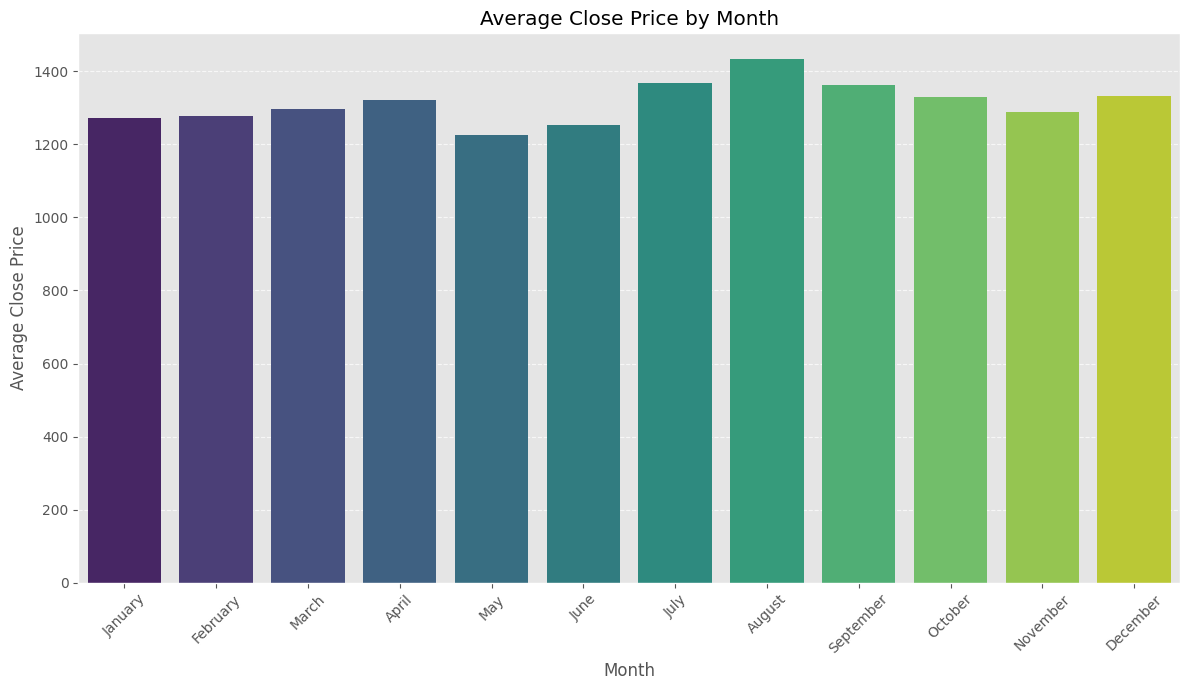

In [ ]:
# Group by month and calculate the average Close Price
monthly_avg_close = df.groupby('Month')['Close Price'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]) # Reindex to ensure correct order of months

plt.figure(figsize=(12, 7))
sns.barplot(x=monthly_avg_close.index, y=monthly_avg_close.values, hue=monthly_avg_close.index, palette='viridis', legend=False)
plt.title('Average Close Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:** The average 'Close Price' varies across months, indicating potential seasonal patterns in stock prices. Some months show higher average closing prices than others.

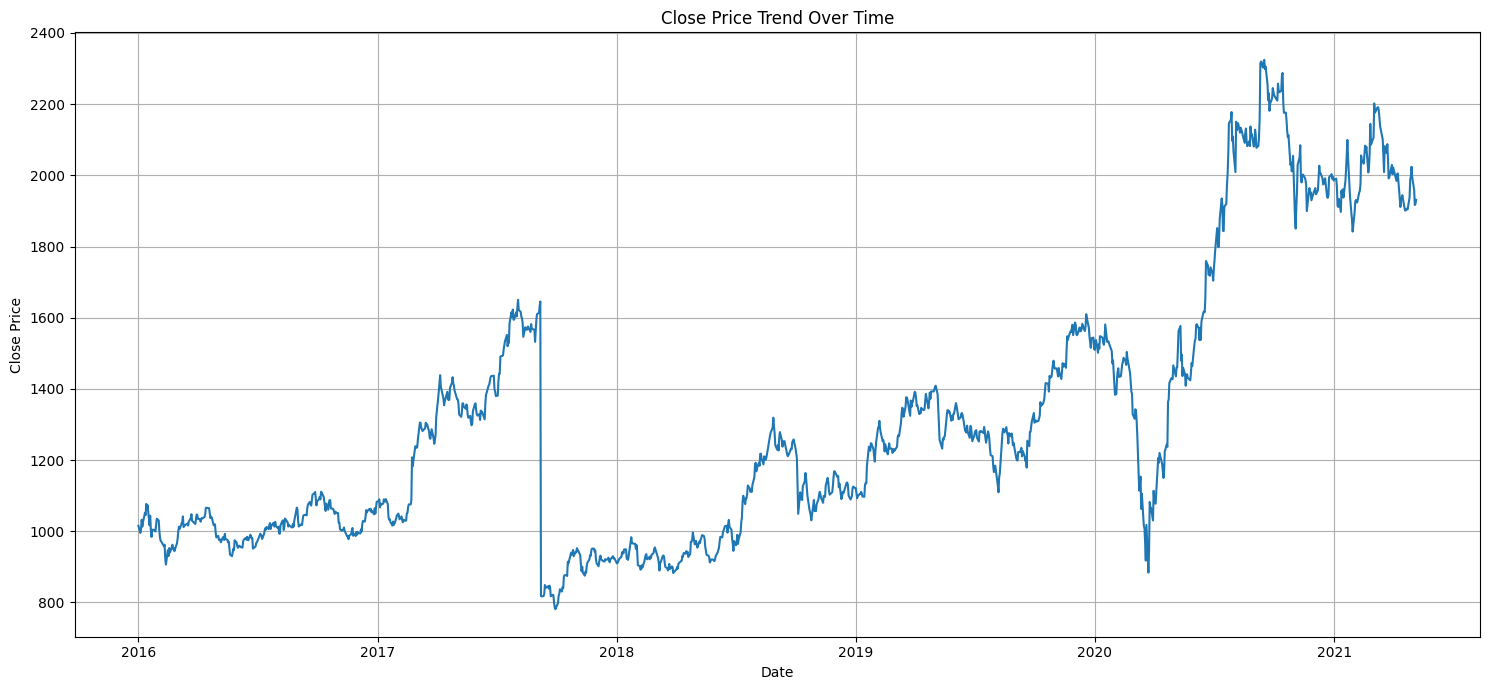

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Close Price', data=df)
plt.title('Close Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** The 'Close Price' exhibits a clear trend over time, showing periods of both upward and downward movement, possibly reflecting broader market cycles or specific events affecting the stock.

### Delivery vs Intraday Trading Share Analysis

This section will analyze the `% Dly Qt to Traded Qty` column, which represents the percentage of deliverable quantity to the total traded quantity. This metric provides insight into the proportion of trades that result in actual delivery (delivery-based trading) versus those that are squared off within the same trading day (intraday or speculative trading).

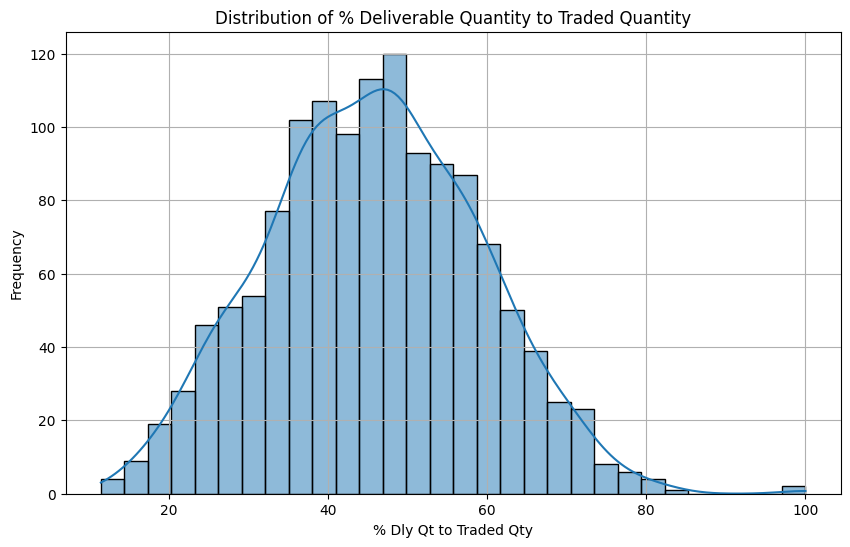

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['% Dly Qt to Traded Qty'], kde=True, bins=30)
plt.title('Distribution of % Deliverable Quantity to Traded Quantity')
plt.xlabel('% Dly Qt to Traded Qty')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**Insight:** The distribution of '% Dly Qt to Traded Qty' shows that a significant portion of trading involves deliverable quantities in a particular range, providing insight into the prevailing nature of trades (intraday vs. delivery-based).

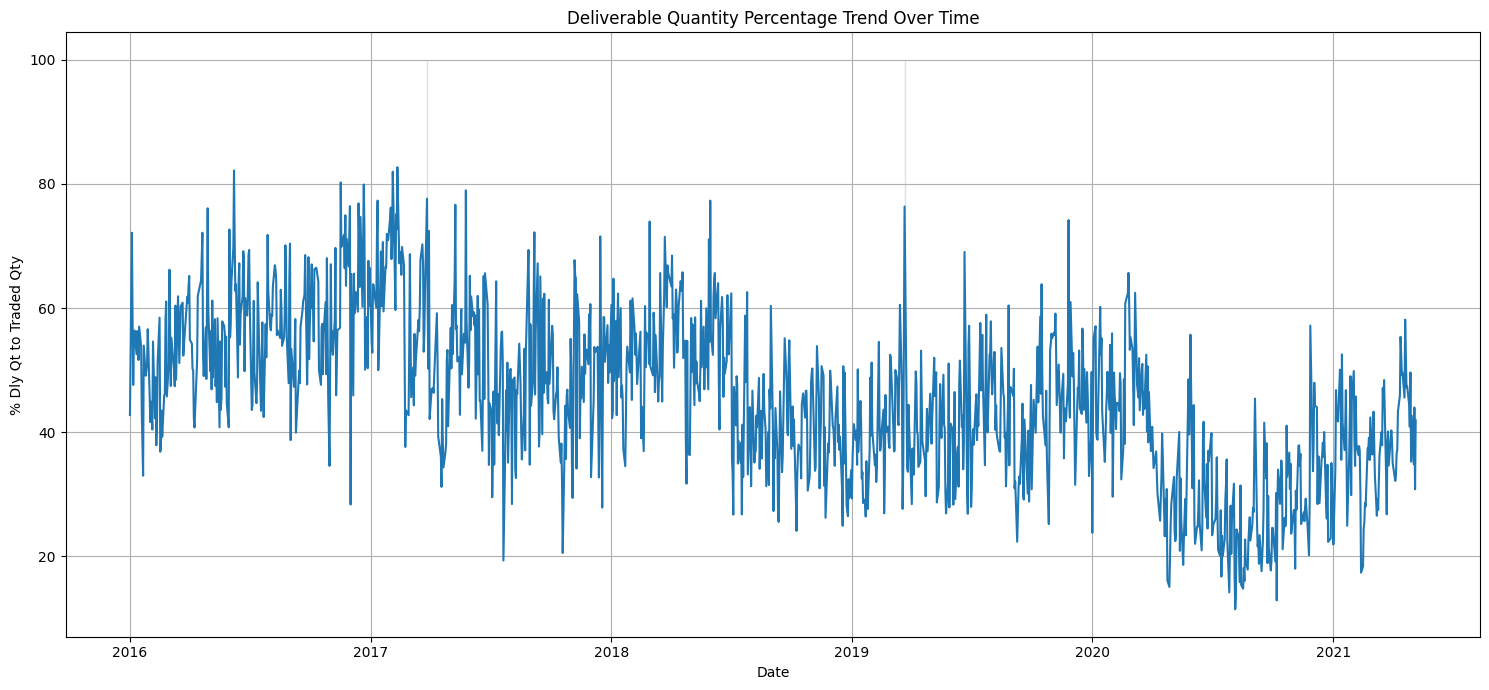

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='% Dly Qt to Traded Qty', data=df)
plt.title('Deliverable Quantity Percentage Trend Over Time')
plt.xlabel('Date')
plt.ylabel('% Dly Qt to Traded Qty')
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** The trend of '% Dly Qt to Traded Qty' over time can reveal shifts in investor sentiment, with higher percentages indicating more long-term investment activity and lower percentages suggesting increased short-term or speculative trading.

### Average Price vs Close Price

This section will visualize the relationship between 'Average Price' and 'Close Price' to see how closely they align over time. The insight here is that the market closing price generally follows average traded price trends.

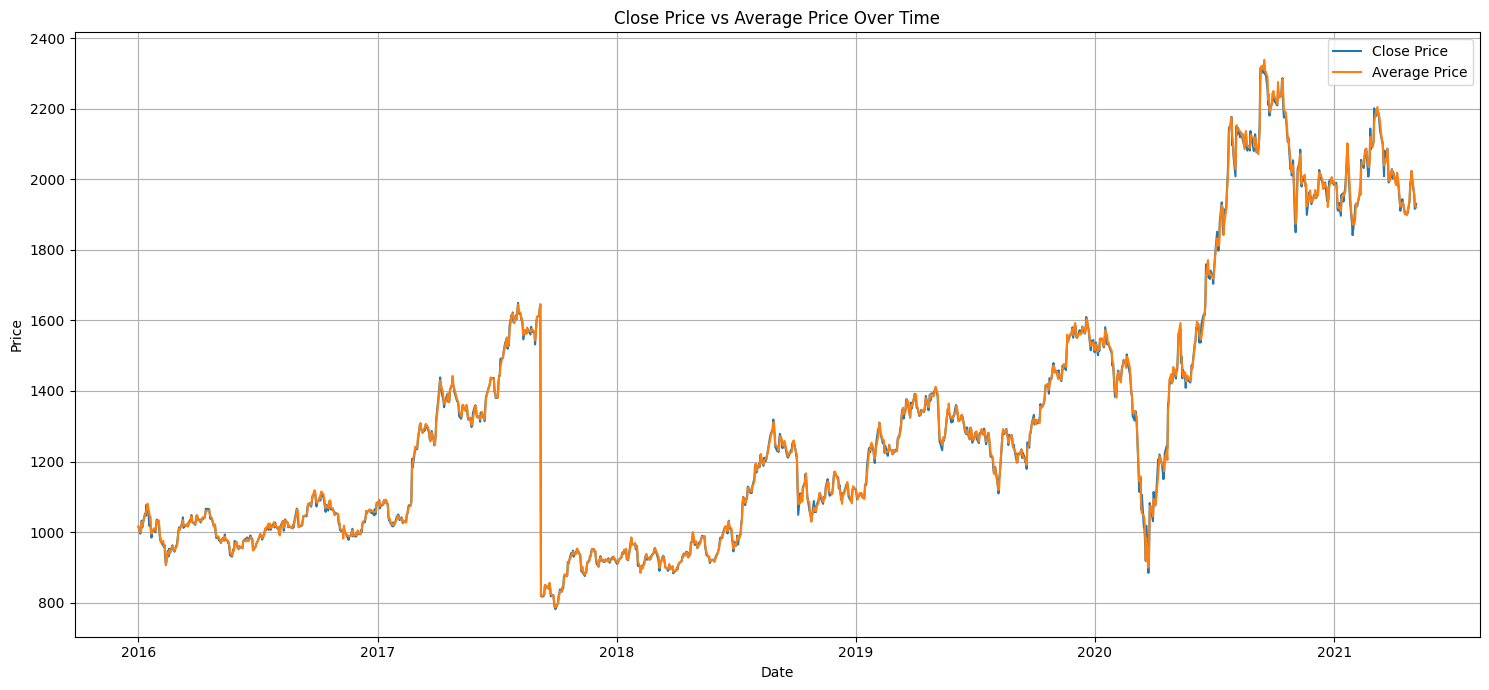

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Close Price', data=df, label='Close Price')
sns.lineplot(x='Date', y='Average Price', data=df, label='Average Price')
plt.title('Close Price vs Average Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** The 'Close Price' and 'Average Price' track each other very closely over time, suggesting that the closing price is generally representative of the average trading activity throughout the day.

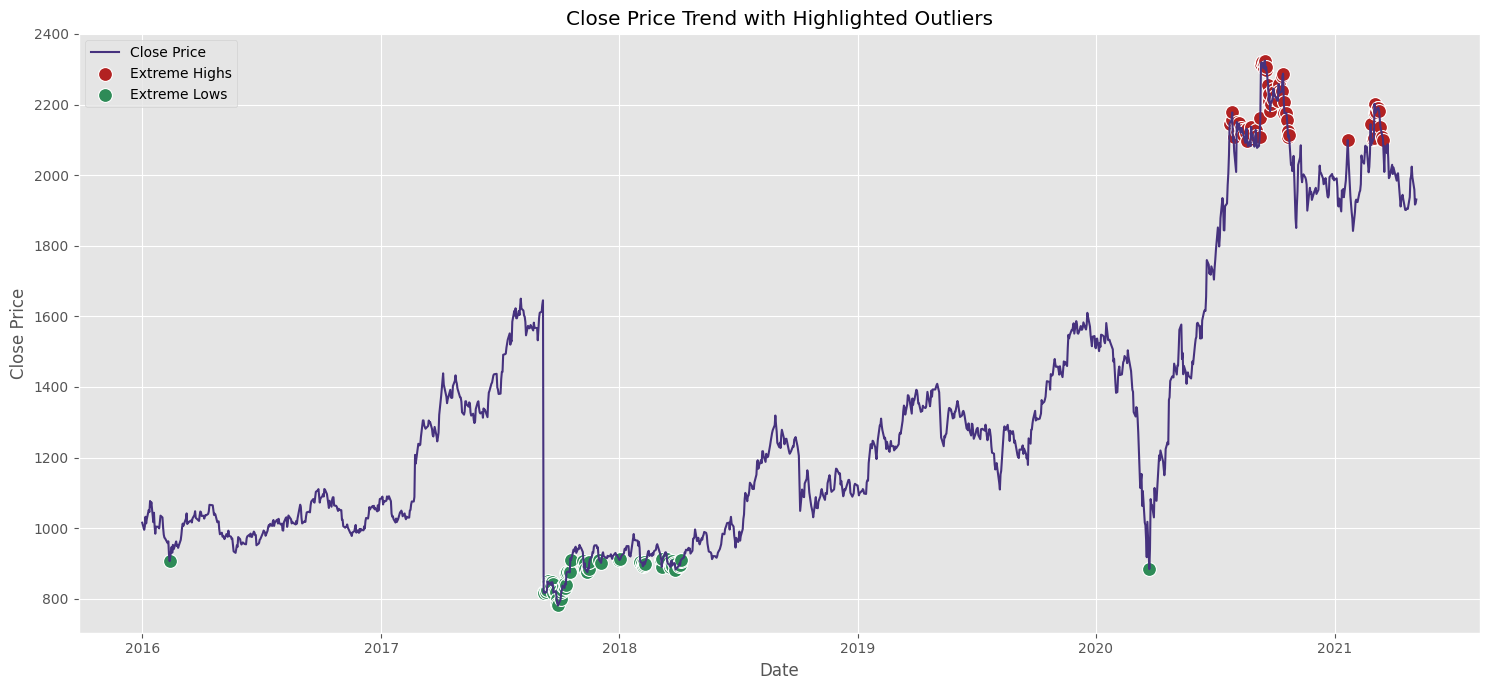

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Close Price', data=df, label='Close Price')

# Calculate thresholds for highlighting (e.g., 95th and 5th percentiles)
upper_threshold = df['Close Price'].quantile(0.95)
lower_threshold = df['Close Price'].quantile(0.05)

# Highlight points above upper threshold
outliers_upper = df[df['Close Price'] >= upper_threshold]
sns.scatterplot(x='Date', y='Close Price', data=outliers_upper, color='firebrick', s=100, label='Extreme Highs') # Changed color to 'firebrick'

# Highlight points below lower threshold
outliers_lower = df[df['Close Price'] <= lower_threshold]
sns.scatterplot(x='Date', y='Close Price', data=outliers_lower, color='seagreen', s=100, label='Extreme Lows') # Changed color to 'seagreen'

plt.title('Close Price Trend with Highlighted Outliers')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** The visualization highlights periods of extreme 'Close Price' movements, identifying days where the stock traded significantly above or below its typical range, which could be indicative of major news or market events.

### Deliverable Quantity Contribution Analysis

This section will analyze the distribution of the `% Dly Qt to Traded Qty` by grouping it into ranges and visualizing these contributions with a pie chart. This will highlight how the percentage of delivery-based trading varies, indicating sessions with different levels of long-term investment vs. intraday speculation.

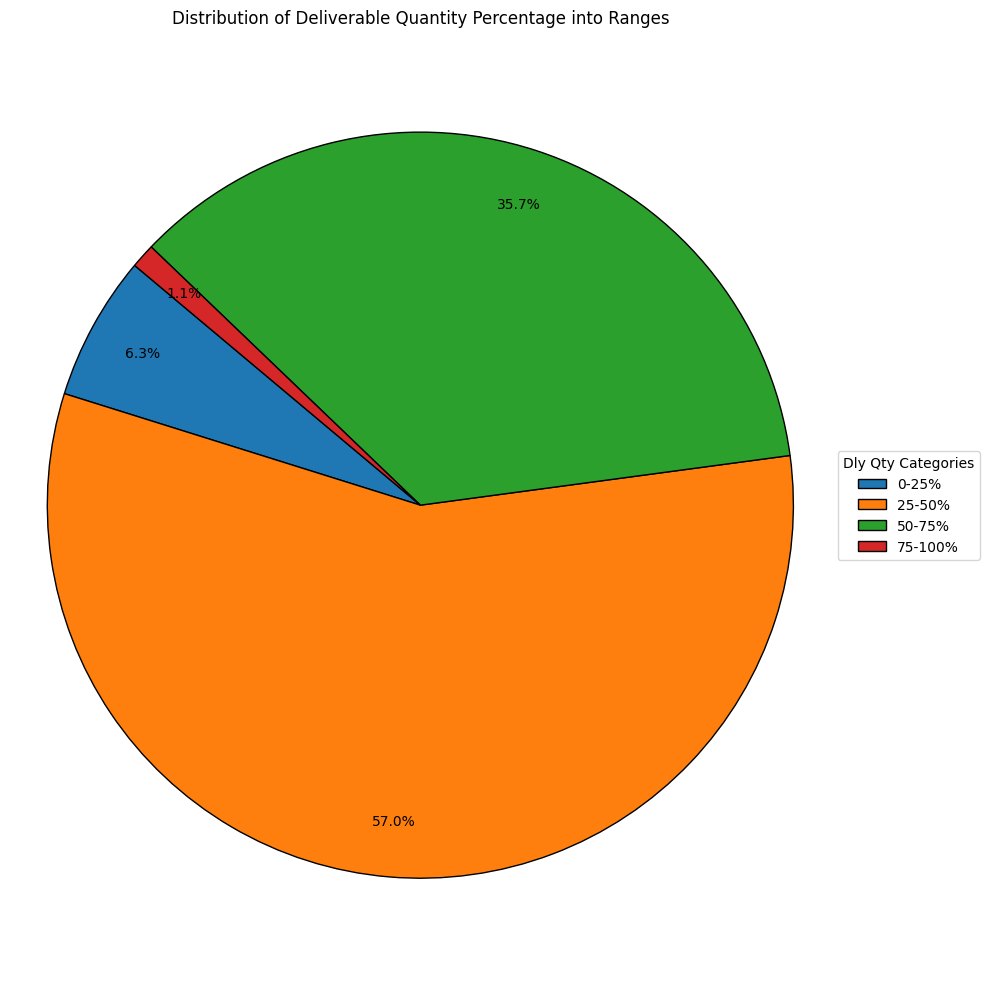

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define ranges for '% Dly Qt to Traded Qty'
bins = [0, 25, 50, 75, 100]
labels = ['0-25%', '25-50%', '50-75%', '75-100%']

# Categorize the data into these ranges
df['Dly_Qty_Category'] = pd.cut(df['% Dly Qt to Traded Qty'], bins=bins, labels=labels, right=False)

# Calculate the count for each category
category_counts = df['Dly_Qty_Category'].value_counts().sort_index()

# Create the pie chart
plt.figure(figsize=(10, 10))
wedges, texts, autotexts = plt.pie(category_counts, autopct='%1.1f%%', startangle=140, pctdistance=0.85, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Deliverable Quantity Percentage into Ranges')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Add a legend outside the pie chart
plt.legend(wedges, category_counts.index, title="Dly Qty Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

**Insight:** The pie chart illustrates that a substantial majority of trading sessions fall within the 25-75% deliverable quantity range, suggesting a balance between intraday speculation and delivery-based trading. Extreme high or low deliverable quantities are less common.

### Turnover vs Number of Trades

This section explores the relationship between the number of trades and the total turnover, with the size of the bubbles representing the total traded quantity. This helps to visualize how trading activity impacts market turnover.

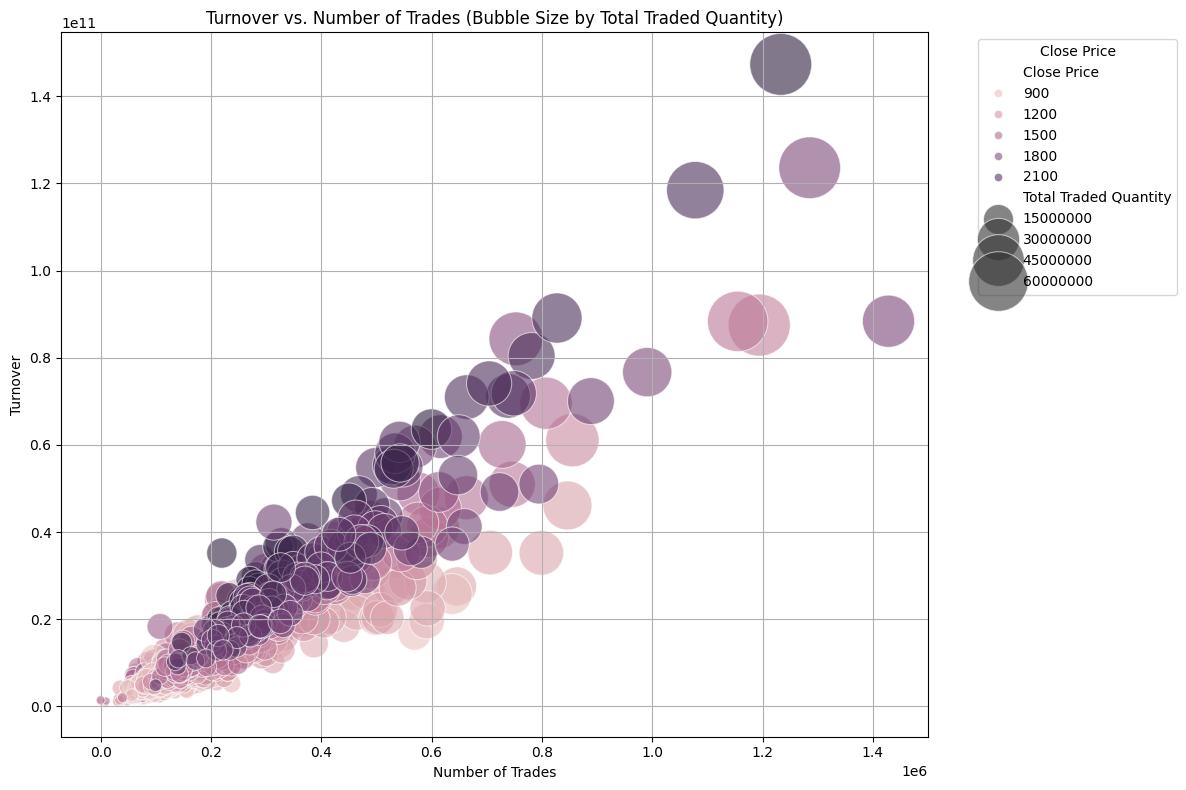

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='No. of Trades',
    y='Turnover',
    size='Total Traded Quantity',
    hue='Close Price', # Using Close Price for color to add another dimension
    data=df,
    sizes=(20, 2000),
    alpha=0.6
)
plt.title('Turnover vs. Number of Trades (Bubble Size by Total Traded Quantity)')
plt.xlabel('Number of Trades')
plt.ylabel('Turnover')
plt.grid(True)
plt.legend(title='Close Price', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight:** Higher trades generally lead to higher turnover. Trading activity directly impacts market turnover.

### Monthly Trading Activity

This section analyzes the total traded quantity on a monthly basis to identify periods of higher or lower trading activity.

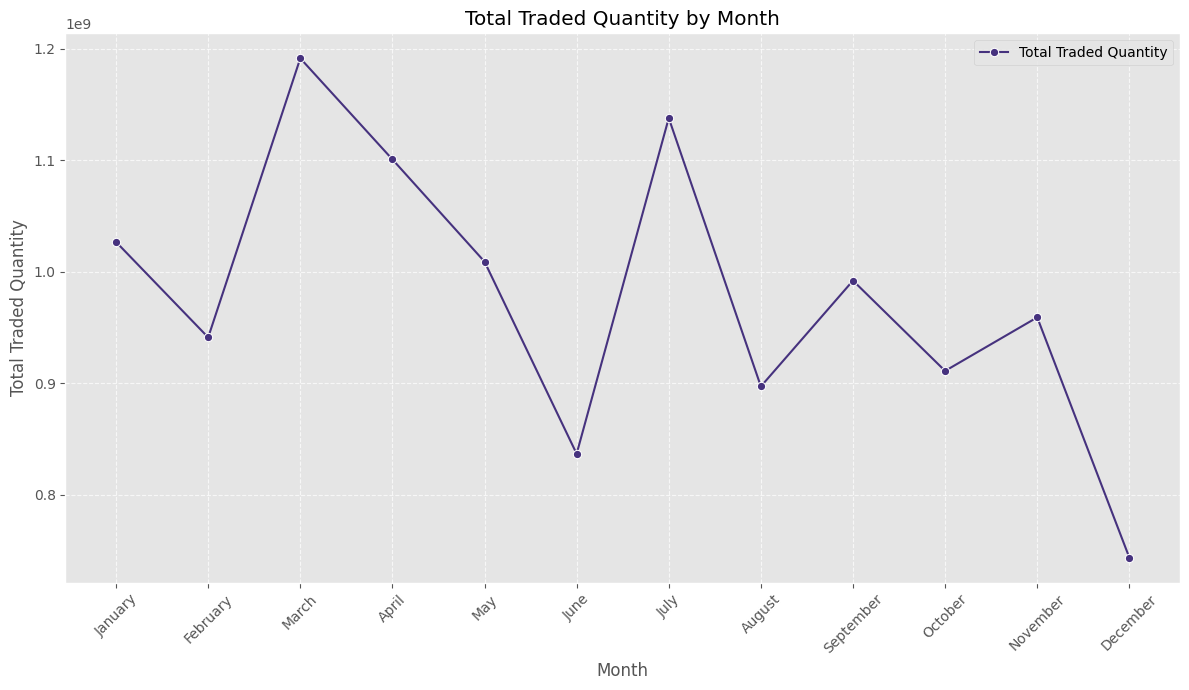

In [ ]:
# Group by month and calculate the total traded quantity
monthly_traded_qty = df.groupby('Month')['Total Traded Quantity'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

plt.figure(figsize=(12, 7))
sns.lineplot(x=monthly_traded_qty.index, y=monthly_traded_qty.values, marker='o', label='Total Traded Quantity') # Removed 'color'
plt.title('Total Traded Quantity by Month')
plt.xlabel('Month')
plt.ylabel('Total Traded Quantity')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** The 'Total Traded Quantity' exhibits noticeable monthly variations. March, April, and July typically show higher trading activity, while June and December tend to have lower trading volumes. This indicates potential seasonal patterns in market engagement for this stock.

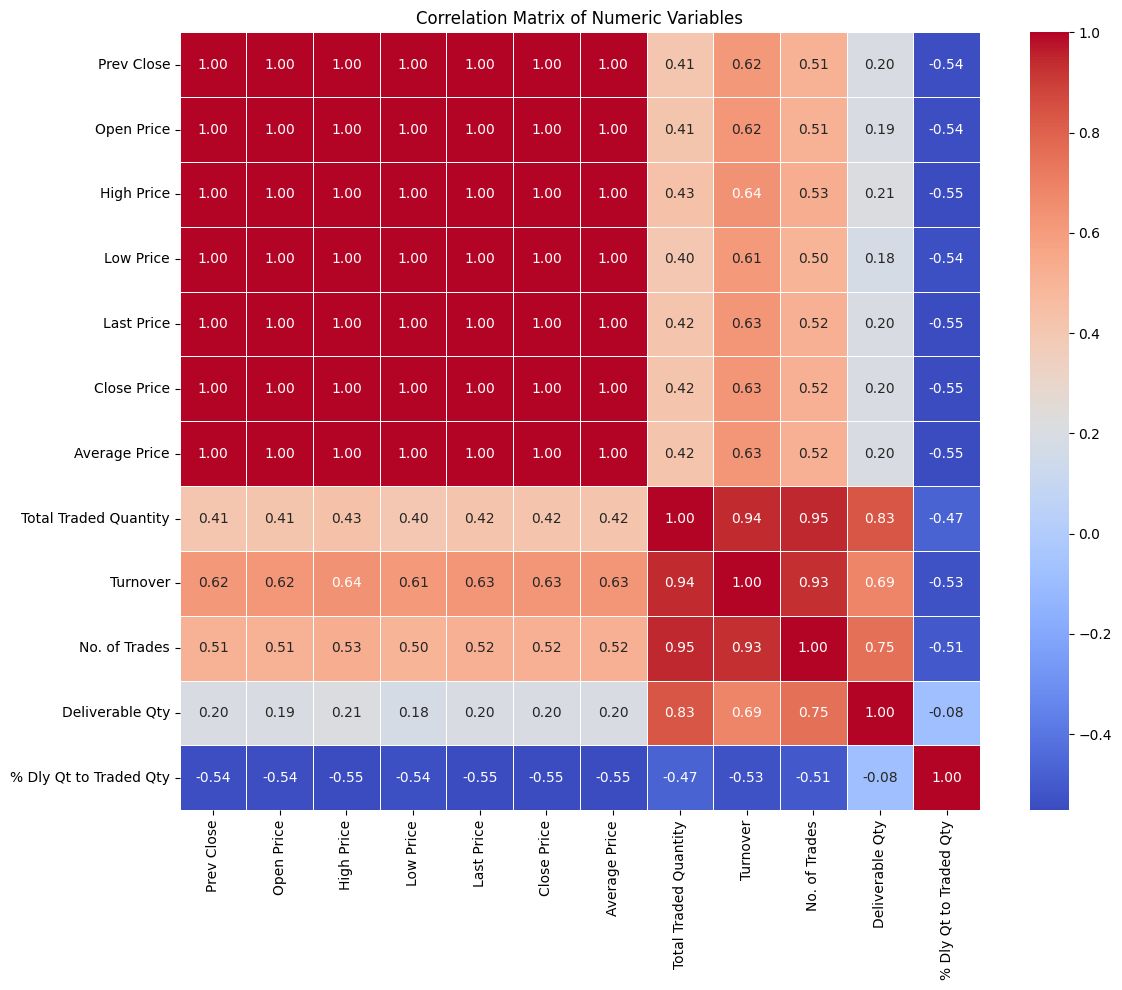

In [ ]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

**Insight:** Price variables are highly correlated, while volume behaves differently.

**Insight:** Some months show higher activity than others. Trading activity varies seasonally.